# Inversión Sísmica — Terremoto de Copiapó (6 de Junio de 2025)

Este notebook implementa la inversión de forma de onda completa usando el método del **Vecino más Cercano (Neighbourhood Algorithm)** para estimar los parámetros de ruptura del terremoto de Copiapó.

## Flujo de trabajo

1. **Configuración** — importaciones, rutas y lectura del archivo `input.ctl`
2. **Carga de datos** — formas de onda observadas y filtrado
3. **Verificación** — visualización de sismogramas observados y mapa de estaciones
4. **Tiempos de arribo** — cálculo de tiempos P/S por azimut
5. **Modelo forward** — construcción del modelo AXITRA
6. **Inversión NA** — configuración y ejecución de la búsqueda
7. **Resultados** — análisis del modelo óptimo y visualización

---
## 1. Configuración del entorno

In [1]:
from pathlib import Path
import sys
import os

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Localizar la raíz del proyecto ──────────────────────────────────────────
def find_project_root(start: Path) -> Path:
    """Sube por los directorios hasta encontrar la carpeta kdellipspy."""
    for p in [start, *start.parents]:
        if (p / 'kdellipspy').exists():
            return p
    raise FileNotFoundError(
        'No se encontró PROJECT_ROOT. '
        'Asegúrate de que exista la carpeta kdellipspy en algún directorio padre.'
    )

root = find_project_root(Path(os.getcwd()))
sys.path.insert(0, str(root))
print(f"Raíz del proyecto: {root}")

import kdellipspy as kde
print(f"kdellipspy cargado correctamente")

Raíz del proyecto: /home/alex/KDEllipsPy
kdellipspy cargado correctamente


### 1.1 Rutas del evento

In [2]:
# ── Rutas principales ────────────────────────────────────────────────────────
EVENT_NAME  = 'copiapo-06-06-2025'
input_ctl   = root / 'inversions' / EVENT_NAME / 'input.ctl'
data_dir    = input_ctl.parent / 'DATA'
axitra_dir  = root / 'kdellipspy' / 'AXITRA2024'
output_dir  = input_ctl.parent / 'output'
output_dir.mkdir(exist_ok=True)

# Verificar que existen
assert input_ctl.exists(),  f"No se encontró input.ctl en {input_ctl}"
assert data_dir.exists(),   f"No se encontró directorio DATA en {data_dir}"
assert axitra_dir.exists(), f"No se encontró AXITRA2024 en {axitra_dir}"

print(f"input.ctl  : {input_ctl}")
print(f"DATA       : {data_dir}")
print(f"AXITRA2024 : {axitra_dir}")
print(f"Salida     : {output_dir}")

input.ctl  : /home/alex/KDEllipsPy/inversions/copiapo-06-06-2025/input.ctl
DATA       : /home/alex/KDEllipsPy/inversions/copiapo-06-06-2025/DATA
AXITRA2024 : /home/alex/KDEllipsPy/kdellipspy/AXITRA2024
Salida     : /home/alex/KDEllipsPy/inversions/copiapo-06-06-2025/output


### 1.2 Lectura de la configuración

In [3]:
cfg = kde.ConfigParser(filepath=input_ctl)

# Resumen del evento
print("=" * 50)
print(f"  Evento     : {cfg.source_position.event_name}")
print(f"  Latitud    : {cfg.source_position.latitude}")
print(f"  Longitud   : {cfg.source_position.longitude}")
print(f"  Profundidad: {cfg.source_position.depth} km")
print(f"  Strike     : {cfg.source_position.strike}°")
print(f"  Dip        : {cfg.source_position.dip}°")
print(f"  Rake       : {cfg.source_position.rake}°")
print("-" * 50)
print(f"  Estaciones : {len(cfg.stations.stations)}")
print(f"  Frecuencias: {cfg.ellipse.freq1} – {cfg.ellipse.freq2} Hz")
print(f"  Ventana    : {cfg.observed_data.t1} – {cfg.observed_data.t2} s")
print(f"  Delta      : {cfg.observed_data.delta} s")
print("=" * 50)

# Lista de estaciones
print("\nEstaciones:")
for i, st in enumerate(cfg.stations.stations):
    print(f"  [{i+1:02d}] {st.name:8s}  lat={st.latitude:.4f}  lon={st.longitude:.4f}")

  Evento     : Event Copiapo 2025 INTRAPLATE
  Latitud    : -26.639
  Longitud   : -70.404
  Profundidad: 75.0 km
  Strike     : 72.0°
  Dip        : 47.0°
  Rake       : -111.0°
--------------------------------------------------
  Estaciones : 10
  Frecuencias: 0.03 – 0.1 Hz
  Ventana    : 0.0 – 204.8 s
  Delta      : 0.2 s

Estaciones:
  [01] A24F      lat=-23.6100  lon=-70.2620
  [02] PB19      lat=-23.9050  lon=-69.2910
  [03] GO02      lat=-25.1626  lon=-69.5904
  [04] AC01      lat=-26.1480  lon=-70.5990
  [05] A30C      lat=-27.0700  lon=-70.8200
  [06] A18C      lat=-27.5030  lon=-70.8870
  [07] AC04      lat=-28.2050  lon=-71.0740
  [08] A10C      lat=-28.5800  lon=-70.7580
  [09] AC05      lat=-28.8360  lon=-70.2740
  [10] A32C      lat=-29.1020  lon=-71.4100


---
## 2. Carga y filtrado de datos observados

In [4]:
observed_waveforms, time_array = kde.load_and_filter_observed_data(
    freq1=cfg.ellipse.freq1,
    freq2=cfg.ellipse.freq2,
    input_ctl_path=str(input_ctl),
    data_dir=str(data_dir),
    prefer_raw=False,
)

n_stations, n_components, n_samples = observed_waveforms.shape
dt = time_array[1] - time_array[0]

print(f"Formas de onda cargadas: {observed_waveforms.shape}")
print(f"  Estaciones  : {n_stations}")
print(f"  Componentes : {n_components}  (0=Z, 1=N, 2=E)")
print(f"  Muestras    : {n_samples}")
print(f"  dt          : {dt:.4f} s")
print(f"  Duración    : {time_array[-1]:.1f} s")

Formas de onda cargadas: (10, 3, 1024)
  Estaciones  : 10
  Componentes : 3  (0=Z, 1=N, 2=E)
  Muestras    : 1024
  dt          : 0.2000 s
  Duración    : 204.6 s


---
## 3. Verificación de los datos

### 3.1 Sismogramas observados (ordenados por azimut, con ventanas P/S)

In [7]:
azi_times_array = None

try:
    azi_times_array = kde.build_azi_times_array(input_ctl_path=input_ctl)
    print(f"azi_times generado: shape={azi_times_array.shape}")
    print(f"  Columnas: [azimuth_deg, t_P, t_S]  — filas en orden de cfg.stations")
except Exception as e:
    raise RuntimeError(
        "No se pudo generar azi_times. "
        "Verifica que ObsPy y el modelo de velocidades estén configurados correctamente."
    ) from e

print(f"\nDatos observados: {observed_waveforms.shape}")
print("Listo para la inversión.")

azi_times generado: shape=(10, 3)
  Columnas: [azimuth_deg, t_P, t_S]  — filas en orden de cfg.stations

Datos observados: (10, 3, 1024)
Listo para la inversión.


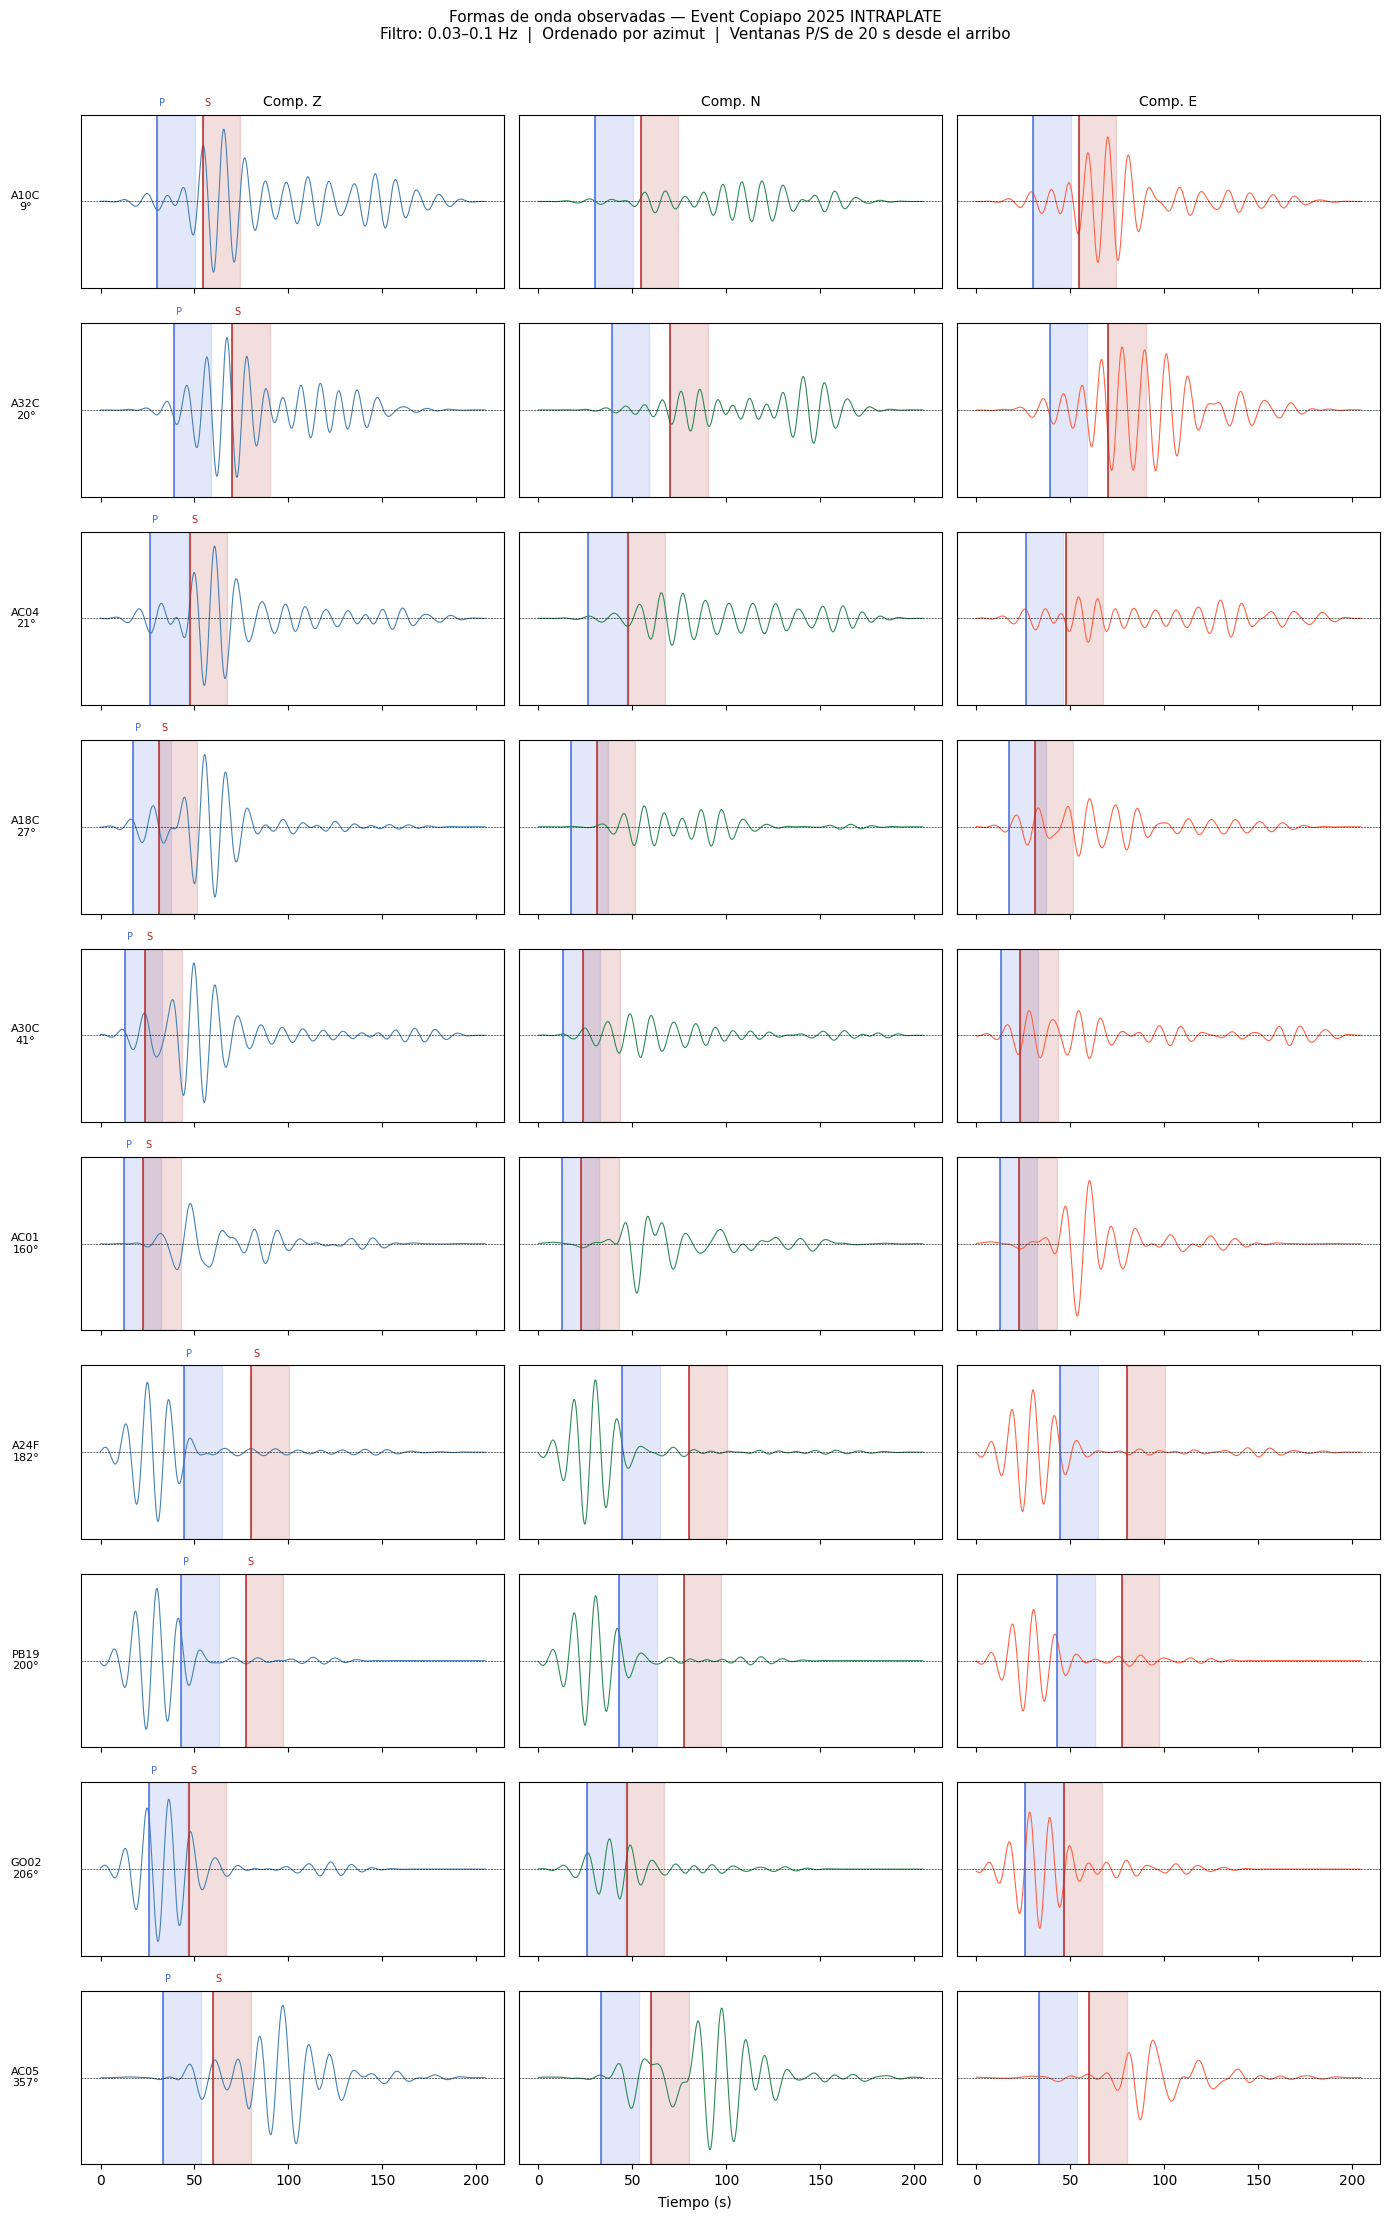

Figura guardada en /home/alex/KDEllipsPy/inversions/copiapo-06-06-2025/output/observed_waveforms.png


In [8]:
COMP_LABELS = ['Z', 'N', 'E']
COMP_COLORS = ['steelblue', 'seagreen', 'tomato']
# Duración de la ventana de misfit — igual que en MisfitCalculator (time_window_s=20.0)
# La ventana va de t_P a t_P + WIN_S (inicio en el arribo, no centrada)
WIN_S = 20.0

# ── Calcular azimuts para ordenar estaciones ─────────────────────────────────
# azi_times_array shape: (n_stations, 3)
# columnas: [azimuth_rad, t_P, t_S] — filas en el mismo orden que cfg.stations
azi_info = {}  # {0-based station index: (azimuth_rad, t_P, t_S)}
if azi_times_array is not None:
    for i, row in enumerate(azi_times_array):
        azi_info[i] = (float(row[0]), float(row[1]), float(row[2]))

# Orden ascendente por azimut
station_order = sorted(
    range(n_stations),
    key=lambda i: azi_info.get(i, (999,))[0]
)

# ── Figura ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    n_stations, n_components,
    figsize=(14, 2.2 * n_stations),
    sharex=True,
)
if n_stations == 1:
    axes = axes[np.newaxis, :]

for row_idx, i in enumerate(station_order):
    station  = cfg.stations.stations[i]
    row_max  = np.abs(observed_waveforms[i]).max() or 1.0
    azi_rad, t_p, t_s = azi_info.get(i, (None, None, None))
    azi_deg = np.degrees(azi_rad) if azi_rad is not None else None

    for j in range(n_components):
        ax = axes[row_idx, j]
        ax.plot(time_array, observed_waveforms[i, j] / row_max,
                color=COMP_COLORS[j], lw=0.8)
        ax.axhline(0, color='k', lw=0.4, ls='--')

        # Ventanas P y S: inicio en el arribo, duración WIN_S
        # Consistente con MisfitCalculator.l2_misfit:
        #   kp0 = t_P * sampling,  kp1 = kp0 + win
        #   ks0 = t_S * sampling,  ks1 = ks0 + win
        if t_p is not None:
            ax.axvspan(t_p, t_p + WIN_S, alpha=0.15, color='royalblue', zorder=0)
            ax.axvline(t_p, color='royalblue', lw=1.2, ls='-', alpha=0.9)
            if j == 0:
                ax.text(t_p + WIN_S * 0.05, 1.05, 'P', color='royalblue',
                        fontsize=7, ha='left', transform=ax.get_xaxis_transform())
        if t_s is not None:
            ax.axvspan(t_s, t_s + WIN_S, alpha=0.15, color='firebrick', zorder=0)
            ax.axvline(t_s, color='firebrick', lw=1.2, ls='-', alpha=0.9)
            if j == 0:
                ax.text(t_s + WIN_S * 0.05, 1.05, 'S', color='firebrick',
                        fontsize=7, ha='left', transform=ax.get_xaxis_transform())

        ax.set_ylim(-1.2, 1.2)
        ax.set_yticks([])
        if row_idx == 0:
            ax.set_title(f'Comp. {COMP_LABELS[j]}', fontsize=10)
        if j == 0:
            label = station.name
            if azi_deg is not None:
                label += f'\n{azi_deg:.0f}°'
            ax.set_ylabel(label, fontsize=8, rotation=0,
                          labelpad=40, va='center')

fig.supxlabel('Tiempo (s)', fontsize=10)
fig.suptitle(
    f'Formas de onda observadas — {cfg.source_position.event_name}\n'
    f'Filtro: {cfg.ellipse.freq1}–{cfg.ellipse.freq2} Hz  |  '
    f'Ordenado por azimut  |  Ventanas P/S de {WIN_S:.0f} s desde el arribo',
    fontsize=11, y=1.01
)
plt.tight_layout()
fig.savefig(output_dir / 'observed_waveforms.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figura guardada en {output_dir / 'observed_waveforms.png'}")

### 3.2 Visualización con ObsPy (opcional)

In [ ]:
try:
    import obspy
    st = obspy.Stream()
    for i, station in enumerate(cfg.stations.stations):
        for j, comp in enumerate(COMP_LABELS):
            tr = obspy.Trace(data=observed_waveforms[i, j].copy())
            tr.stats.station   = station.name
            tr.stats.channel   = f'HH{comp}'
            tr.stats.starttime = obspy.UTCDateTime(0)
            tr.stats.delta     = dt
            st.append(tr)
    st.plot(size=(1000, 800))
except ImportError:
    print("ObsPy no está instalado — se omite este bloque.")
    print("Instala con: pip install obspy")

### 3.3 Mapa de estaciones y epicentro

In [ ]:
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    src_lat = float(cfg.source_position.latitude)
    src_lon = float(cfg.source_position.longitude)
    sta_lats = [float(s.latitude)  for s in cfg.stations.stations]
    sta_lons = [float(s.longitude) for s in cfg.stations.stations]
    sta_names = [s.name for s in cfg.stations.stations]

    pad = 3.0
    extent = [
        min(sta_lons + [src_lon]) - pad,
        max(sta_lons + [src_lon]) + pad,
        min(sta_lats + [src_lat]) - pad,
        max(sta_lats + [src_lat]) + pad,
    ]

    fig, ax = plt.subplots(
        figsize=(7, 7),
        subplot_kw={'projection': ccrs.PlateCarree()}
    )
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND,   facecolor='#f0ede8')
    ax.add_feature(cfeature.OCEAN,  facecolor='#cce5f5')
    ax.add_feature(cfeature.BORDERS, linewidth=0.6, edgecolor='gray')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.gridlines(draw_labels=True, linewidth=0.4, linestyle='--', color='gray')

    # Epicentro
    ax.plot(src_lon, src_lat, '*', color='red', markersize=18,
            transform=ccrs.PlateCarree(), zorder=5, label='Epicentro')

    # Estaciones
    ax.scatter(sta_lons, sta_lats, marker='^', s=80, color='navy',
               transform=ccrs.PlateCarree(), zorder=5, label='Estaciones')
    for name, lon, lat in zip(sta_names, sta_lons, sta_lats):
        ax.text(lon + 0.1, lat + 0.1, name, fontsize=7,
                transform=ccrs.PlateCarree(), color='navy')

    # Líneas epicentro–estación
    for lon, lat in zip(sta_lons, sta_lats):
        ax.plot([src_lon, lon], [src_lat, lat], 'k--', lw=0.5, alpha=0.4,
                transform=ccrs.PlateCarree())

    ax.set_title(
        f"{cfg.source_position.event_name}\n"
        f"({src_lat:.3f}°, {src_lon:.3f}°)  Prof: {cfg.source_position.depth} km",
        fontsize=10
    )
    ax.legend(loc='lower left', fontsize=8)
    plt.tight_layout()
    fig.savefig(output_dir / 'station_map.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Mapa guardado en {output_dir / 'station_map.png'}")

except ImportError:
    print("Cartopy no está instalado — se omite el mapa.")
    print("Instala con: pip install cartopy")

---
## 4. Tiempos de arribo P/S por azimut

In [ ]:
azi_times_array = None

try:
    azi_times_array = kde.build_azi_times_array(input_ctl_path=input_ctl)
    print(f"azi_times generado: shape={azi_times_array.shape}")
    print(f"  Columnas: [azimuth_deg, t_P, t_S]  — filas en orden de cfg.stations")
except Exception as e:
    raise RuntimeError(
        "No se pudo generar azi_times. "
        "Verifica que ObsPy y el modelo de velocidades estén configurados correctamente."
    ) from e

print(f"\nDatos observados: {observed_waveforms.shape}")
print("Listo para la inversión.")

azi_times generado: shape=(10, 3)
  Columnas: [azimuth_deg, t_P, t_S]  — filas en orden de cfg.stations

Datos observados: (10, 3, 512)
Listo para la inversión.


---
## 5. Construcción del modelo forward

In [ ]:
inversion = kde.NAInversionModel(
    str(input_ctl),
    axitra_dir=str(axitra_dir),
    observed_waveforms=observed_waveforms,
    time_array=time_array,
    azi_times_array=azi_times_array,
)

# Verificar espacio de parámetros
# InversionParams expone una lista .parameters donde cada elemento
# tiene los atributos .name, .min_val y .max_val (igual que NAInversionModel)
print("Parámetros de inversión:")
print("-" * 50)
ip = cfg.inversion_params
param_names = ['a1 (km)', 'a2 (km)', 'theta (×π)', 'np', 'tp (×2π)', 'dmax (m)', 'vr (km/s)']
param_mins  = [p.min_val for p in ip.parameters]
param_maxs  = [p.max_val for p in ip.parameters]
for name, pobj, vmin, vmax in zip(param_names, ip.parameters, param_mins, param_maxs):
    print(f"  {name:15s}: [{vmin:8.3f}, {vmax:8.3f}]  ({pobj.name.strip()})")

---
## 6. Inversión con Neighbourhood Algorithm (NA)

### 6.1 Configuración del NA

In [ ]:
na_config = kde.NAConfig(
    n_samples_initial  = 50,   # muestras en la primera iteración (exploración global)
    n_samples_iteration= 20,   # muestras por iteración siguiente
    n_iterations       = 10,   # número de iteraciones de refinamiento
    n_cells_resample   = 10,   # celdas de Voronoi con mejor misfit a refinar
    random_seed        = 42,   # reproducibilidad (None = aleatorio)
)

total_evals = na_config.n_samples_initial + na_config.n_samples_iteration * na_config.n_iterations
print(f"Total de evaluaciones del forward model: {total_evals}")
print(f"  Fase inicial   : {na_config.n_samples_initial}")
print(f"  Iteraciones    : {na_config.n_iterations} × {na_config.n_samples_iteration} = "
      f"{na_config.n_iterations * na_config.n_samples_iteration}")
print(f"  Celdas a refinar por iteración: {na_config.n_cells_resample}")

### 6.2 Ejecución de la búsqueda

In [ ]:
print("Iniciando inversión NA...")
print("(Esto puede tardar varios minutos dependiendo de la configuración)")
print("=" * 60)

result = inversion.run_na_search(na_config)

print("=" * 60)
print("Inversión finalizada.")

[NA] iter=002 eval=00088 misfit=1.205190e+02 best=5.898897e+01
[NA] iter=002 eval=00089 misfit=1.147420e+02 best=5.898897e+01
[NA] iter=002 eval=00090 misfit=1.322725e+02 best=5.898897e+01


NAI - Optimisation Loop:  20%|██        | 2/10 [00:39<02:36, 19.53s/it]


BrokenProcessPool: A task has failed to un-serialize. Please ensure that the arguments of the function are all picklable.

---
## 7. Análisis de resultados

### 7.1 Modelo óptimo

In [ ]:
best_model  = result.best_model
best_misfit = result.best_misfit

print("Modelo óptimo encontrado:")
print("=" * 50)
for name, val in zip(param_names, best_model):
    print(f"  {name:15s}: {val:.4f}")
print("-" * 50)
print(f"  Misfit        : {best_misfit:.6f}")

# Estimar momento sísmico y Mw
fm = kde.AxitraForwardModel(str(input_ctl), axitra_dir=str(axitra_dir))
m0, mw = fm.estimate_total_moment_and_mw(best_model)
print(f"  M0            : {m0:.3e} N·m")
print(f"  Mw            : {mw:.2f}")
print("=" * 50)

### 7.2 Convergencia de la inversión

In [ ]:
all_misfits = np.array(result.all_misfits)
all_models  = np.array(result.all_models)

# Misfit mínimo acumulado por evaluación
running_best = np.minimum.accumulate(all_misfits)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Izquierda: todas las evaluaciones + mejor acumulado
ax = axes[0]
ax.scatter(range(len(all_misfits)), all_misfits,
           s=8, alpha=0.4, color='steelblue', label='Todas las muestras')
ax.plot(running_best, color='red', lw=1.5, label='Mejor acumulado')
ax.axvline(na_config.n_samples_initial, color='gray', ls='--',
           lw=1, label='Fin fase inicial')
ax.set_xlabel('Evaluación')
ax.set_ylabel('Misfit')
ax.set_title('Convergencia del NA')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Derecha: distribución del misfit
ax = axes[1]
ax.hist(all_misfits, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(best_misfit, color='red', lw=2, label=f'Mejor misfit = {best_misfit:.4f}')
ax.set_xlabel('Misfit')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución del misfit')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(output_dir / 'convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figura guardada en {output_dir / 'convergence.png'}")

### 7.3 Espacio de parámetros explorado

In [ ]:
# Percentil 10% de mejor misfit para colorear
misfit_thresh = np.percentile(all_misfits, 10)
good_mask = all_misfits <= misfit_thresh

n_params = len(param_names)
fig, axes = plt.subplots(1, n_params, figsize=(3 * n_params, 3.5))

for k, (name, vmin, vmax) in enumerate(zip(param_names, param_mins, param_maxs)):
    ax = axes[k]
    ax.scatter(all_models[:, k], all_misfits,
               s=6, alpha=0.3, color='steelblue')
    ax.scatter(all_models[good_mask, k], all_misfits[good_mask],
               s=10, alpha=0.6, color='orange', label='Top 10%')
    ax.axvline(best_model[k], color='red', lw=1.5, ls='--')
    ax.set_xlabel(name, fontsize=8)
    ax.set_ylabel('Misfit' if k == 0 else '')
    ax.set_xlim(vmin, vmax)
    ax.grid(True, alpha=0.3)
    if k == 0:
        ax.legend(fontsize=7)

fig.suptitle('Espacio de parámetros explorado por el NA', fontsize=11)
plt.tight_layout()
fig.savefig(output_dir / 'parameter_space.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figura guardada en {output_dir / 'parameter_space.png'}")

### 7.4 Comparación: formas de onda observadas vs sintéticas

In [ ]:
# Calcular sintéticos para el modelo óptimo
geometry = fm.build_geometry_with_ellipse_slip(best_model)
ap = fm.build_axitra(geometry)
fm.green(ap, quiet=True)
time_syn, sx, sy, sz = fm.conv(ap, geometry, quiet=True)

# Recortar al mismo largo que los observados si difieren
n_cut = min(n_samples, sx.shape[1])
synthetics = np.stack([sz[:, :n_cut], sx[:, :n_cut], sy[:, :n_cut]], axis=1)  # Z, N, E
t_obs = time_array[:n_cut]
t_syn = time_syn[:n_cut]

fig, axes = plt.subplots(
    n_stations, n_components,
    figsize=(14, 2.2 * n_stations),
    sharex=True,
)
if n_stations == 1:
    axes = axes[np.newaxis, :]

for row_idx, i in enumerate(station_order):
    station  = cfg.stations.stations[i]
    row_max  = max(
        np.abs(observed_waveforms[i]).max(),
        np.abs(synthetics[i]).max(),
    ) or 1.0
    azi, t_p, t_s = azi_info.get(i, (None, None, None))

    for j in range(n_components):
        ax = axes[row_idx, j]
        ax.plot(t_obs, observed_waveforms[i, j, :n_cut] / row_max,
                color='black', lw=1.0, label='Observado')
        ax.plot(t_syn, synthetics[i, j] / row_max,
                color='red', lw=1.0, ls='--', alpha=0.85, label='Sintético')
        ax.axhline(0, color='gray', lw=0.4)

        # Ventanas P y S
        if t_p is not None:
            ax.axvspan(t_p - WIN_HALF, t_p + WIN_HALF,
                       alpha=0.10, color='royalblue', zorder=0)
            ax.axvline(t_p, color='royalblue', lw=1.0, alpha=0.8)
            if j == 0:
                ax.text(t_p, 1.05, 'P', color='royalblue',
                        fontsize=7, ha='center', transform=ax.get_xaxis_transform())
        if t_s is not None:
            ax.axvspan(t_s - WIN_HALF, t_s + WIN_HALF,
                       alpha=0.10, color='firebrick', zorder=0)
            ax.axvline(t_s, color='firebrick', lw=1.0, alpha=0.8)
            if j == 0:
                ax.text(t_s, 1.05, 'S', color='firebrick',
                        fontsize=7, ha='center', transform=ax.get_xaxis_transform())

        ax.set_ylim(-1.3, 1.3)
        ax.set_yticks([])
        if row_idx == 0:
            ax.set_title(f'Comp. {COMP_LABELS[j]}', fontsize=10)
            if j == 0:
                ax.legend(fontsize=7, loc='upper right')
        if j == 0:
            label = station.name
            if azi is not None:
                label += f'\n{azi:.0f}°'
            ax.set_ylabel(label, fontsize=8, rotation=0,
                          labelpad=40, va='center')

fig.supxlabel('Tiempo (s)', fontsize=10)
fig.suptitle(
    f'Observado (negro) vs Sintético (rojo) — Mw {mw:.2f}  |  Misfit {best_misfit:.4f}\n'
    f'Ordenado por azimut  |  Ventanas P/S ±{WIN_HALF:.0f} s',
    fontsize=11, y=1.01
)
plt.tight_layout()
fig.savefig(output_dir / 'waveform_fit.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figura guardada en {output_dir / 'waveform_fit.png'}")

### 7.5 Distribución de deslizamiento

In [ ]:
import matplotlib.colors as mcolors

# Obtener posiciones y deslizamientos de las subfallas
xs   = geometry.x   # along-strike (m)
ys   = geometry.y   # along-dip    (m)
slip = geometry.slip  # (m)

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(
    xs / 1e3, ys / 1e3, c=slip,
    cmap='hot_r', s=60, edgecolors='k', linewidths=0.3,
    norm=mcolors.Normalize(vmin=0, vmax=slip.max())
)
cbar = fig.colorbar(sc, ax=ax, label='Deslizamiento (m)')

# Marcar hipocentro (subfalla con mayor deslizamiento)
hypo_idx = np.argmax(slip)
ax.plot(xs[hypo_idx] / 1e3, ys[hypo_idx] / 1e3,
        '*', color='cyan', ms=14, zorder=5, label='Máx. deslizamiento')

ax.set_xlabel('Along-strike (km)')
ax.set_ylabel('Along-dip (km)')
ax.set_title(
    f'Distribución de deslizamiento — {cfg.source_position.event_name}\n'
    f'dmax={best_model[5]:.2f} m  |  M0={m0:.2e} N·m  |  Mw={mw:.2f}'
)
ax.legend(fontsize=9)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(output_dir / 'slip_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figura guardada en {output_dir / 'slip_distribution.png'}")

---
## 8. Exportación de resultados

In [ ]:
import json

output = {
    'event'       : cfg.source_position.event_name,
    'latitude'    : float(cfg.source_position.latitude),
    'longitude'   : float(cfg.source_position.longitude),
    'depth_km'    : float(cfg.source_position.depth),
    'best_model'  : {name: float(val) for name, val in zip(param_names, best_model)},
    'misfit'      : float(best_misfit),
    'M0_Nm'       : float(m0),
    'Mw'          : float(mw),
    'na_config'   : {
        'n_samples_initial'   : na_config.n_samples_initial,
        'n_samples_iteration' : na_config.n_samples_iteration,
        'n_iterations'        : na_config.n_iterations,
        'n_cells_resample'    : na_config.n_cells_resample,
        'random_seed'         : na_config.random_seed,
    },
}

out_json = output_dir / 'best_model.json'
with open(out_json, 'w', encoding='utf-8') as f:
    json.dump(output, f, indent=2, ensure_ascii=False)

# También guardar todas las muestras
out_samples = output_dir / 'all_samples.npz'
np.savez(out_samples, models=all_models, misfits=all_misfits)

print(f"Resultados exportados:")
print(f"  {out_json}")
print(f"  {out_samples}")
print()
print(json.dumps(output, indent=2, ensure_ascii=False))